In [1]:
from NewtonsMethod import NewtonsMethod
import matplotlib.pyplot as plt
from MultiGridMethod import MultiGrid
from BurgersEquation import BurgerNewtonForm
import numpy as np

In [2]:
dt    = 0.01
numx  = 1000
u0_func = lambda x: 2  + np.sin(np.pi * x)

model   = BurgerNewtonForm(dt, numx, u0_func)
uk = 0.5*( np.concatenate(( np.array([model._u0[-1]]) , model._u0[:-1])) +  model._u0)

preconditioner     = MultiGrid( model )
solver             = NewtonsMethod( model, preconditioner)

preconditioner.MGmaxlvl= 14
preconditioner.CFL     = 0.9
solver.max_ForcingTerm = 1e-10

P_uk1 = solver.solve(uk, model._u0, precondition=True)
model.check_solution(P_uk1)

NEWTON STATUS: Iteration =     0 --- 1.380147165
   GMRES STATUS: Iteration =      0  ||  norm_i = 0.5513303542601041
   GMRES STATUS: Iteration =     10  ||  norm_i = 6.353710421008215e-06
NEWTON STATUS: Iteration =     1 --- 0.001630034
   GMRES STATUS: Iteration =      0  ||  norm_i = 0.0007161020397708225
   GMRES STATUS: Iteration =     10  ||  norm_i = 1.3085538972053302e-08
NEWTON STATUS: Iteration =     2 --- 0.000000025
   GMRES STATUS: Iteration =      0  ||  norm_i = 2.5478331455164044e-09

The algorithm converged after 2 iterations with the 2-norm error: 3.341296714036338e-11
Solution Satisfied


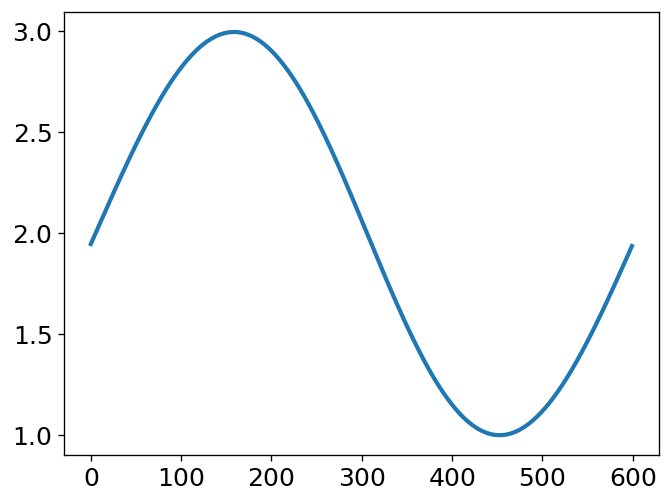

In [6]:
plt.plot(P_uk1)